<a href="https://colab.research.google.com/github/wasmazafira-hash/GPT-Movie/blob/main/GPT_Movie_Success.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd
import numpy as np

np.random.seed(42)

rows = 5000

data= pd.DataFrame({
    'Budget': np.random.randint(20, 300, rows),
    'Runtime': np.random.randint(80, 180, rows),
    'Genre': np.random.choice(['Action', 'Comedy', 'Drama', 'SciFi', 'Horror'], rows),
    'Director_Rating':  np.random.uniform(1, 10, rows),
    'Actor_Popularity': np.random.uniform(1, 10, rows),
    'Marketing_Budget': np.random.uniform(5, 100, rows),
    'Release_Month': np.random.uniform(1, 13, rows)
})

score = (
    data['Budget']*0.3+
    data['Director_Rating']*10+
    data['Actor_Popularity']*12+
    data['Marketing_Budget']*1.5
)
data['Success'] = pd.cut(
    score,
    bins=[0,120,220,1000],
    labels=[0,1,2]
)

data.to_csv("movie_success.csv", index=False)

print("Dataset created successfully!")
data.head()

Dataset created successfully!


,Budget,Runtime,Genre,Director_Rating,Actor_Popularity,Marketing_Budget,Release_Month,Success
0,122,140,Action,3.614334,1.712338,35.564969,1.783264,1
1,290,157,Drama,4.057431,6.286192,54.708203,2.521538,2
2,126,130,SciFi,9.423596,1.282037,67.802958,2.431829,2
3,91,169,Action,2.482669,1.960435,76.160283,12.929227,1
4,208,127,SciFi,1.379354,5.949977,28.360789,3.162236,1


In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
sns.set()

from keras.models import Sequential
from keras.layers import Dense, Dropout
from keras.callbacks import EarlyStopping, ReduceLROnPlateau
from keras.utils import to_categorical

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import confusion_matrix, classification_report

In [ ]:
data = pd.read_csv("movie_success.csv")

print(data.shape)
data.head()

(5000, 8)


,Budget,Runtime,Genre,Director_Rating,Actor_Popularity,Marketing_Budget,Release_Month,Success
0,122,140,Action,3.614334,1.712338,35.564969,1.783264,1
1,290,157,Drama,4.057431,6.286192,54.708203,2.521538,2
2,126,130,SciFi,9.423596,1.282037,67.802958,2.431829,2
3,91,169,Action,2.482669,1.960435,76.160283,12.929227,1
4,208,127,SciFi,1.379354,5.949977,28.360789,3.162236,1


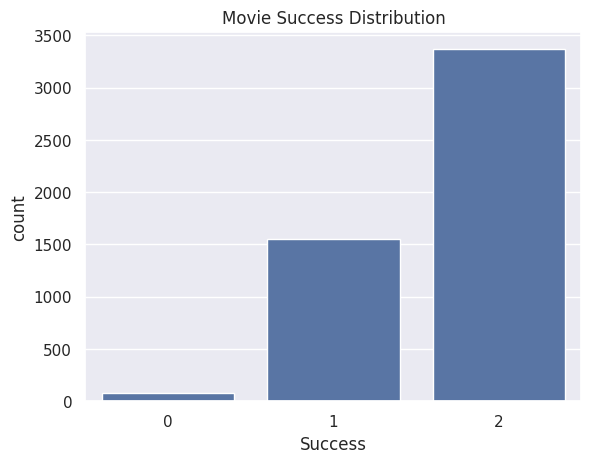

In [ ]:
sns.countplot(x='Success', data=data)
plt.title("Movie Success Distribution")
plt.show()

In [ ]:
encoder = LabelEncoder()

data['Genre'] = encoder.fit_transform(data['Genre'])

In [ ]:
X = data.drop('Success', axis=1)

y = data['Success']

scaler = StandardScaler()

X=scaler.fit_transform(X)

y = to_categorical(y, num_classes=3)

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

In [ ]:
model = Sequential()

model.add(Dense(64, activation='relu', input_shape=(X_train.shape[1],)))
model.add(Dropout(0.3))

model.add(Dense(32, activation='relu'))
model.add(Dropout(0.3))

model.add(Dense(16, activation='relu'))

model.add(Dense(3, activation='softmax'))

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [ ]:
model.compile(
    optimizer='adam',
    loss = 'categorical_crossentropy',
    metrics=['accuracy']
)
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           512 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 3)              │            51 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,171 (12.39 KB)

 Trainable params: 3,171 (12.39 KB)

 Non-trainable params: 0 (0.00 B)

In [ ]:
early_stop = EarlyStopping(
    monitor ='val_loss',
    patience = 5,
    restore_best_weights=True
)

reduce_lr = ReduceLROnPlateau(
    monitor='val_loss',
    patience = 3
)

history = model.fit(
    X_train,
    y_train,
    validation_split=0.2,
    epochs = 50,
    batch_size = 64,
    callbacks=[early_stop, reduce_lr]
)

Epoch 1/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 3s 8ms/step - accuracy: 0.6909 - loss: 0.7092 - val_accuracy: 0.8163 - val_loss: 0.4808 - learning_rate: 0.0010
Epoch 2/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.8556 - loss: 0.3948 - val_accuracy: 0.9275 - val_loss: 0.2593 - learning_rate: 0.0010
Epoch 3/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9034 - loss: 0.2726 - val_accuracy: 0.9413 - val_loss: 0.1960 - learning_rate: 0.0010
Epoch 4/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9200 - loss: 0.2250 - val_accuracy: 0.9463 - val_loss: 0.1681 - learning_rate: 0.0010
Epoch 5/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9334 - loss: 0.1940 - val_accuracy: 0.9563 - val_loss: 0.1411 - learning_rate: 0.0010
Epoch 6/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9353 - loss: 0.1805 - val_accuracy: 0.9563 - val_loss: 0.1299 - learning_rate: 0.0010
Epoch 7/50
50/50 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.9375 - loss: 0.1689 - val_accuracy: 

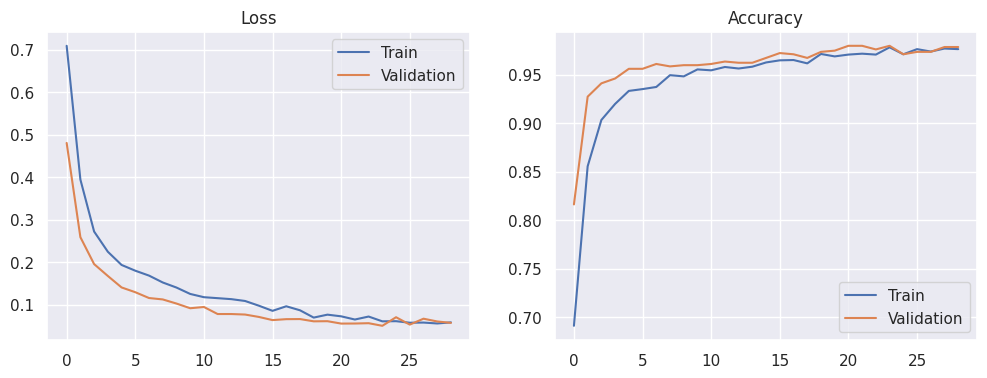

In [ ]:
plt.figure(figsize=(12,4))

plt.subplot(1,2,1)
plt.plot(history.history['loss'])
plt.plot(history.history['val_loss'])
plt.legend(['Train', 'Validation'])
plt.title('Loss')

plt.subplot(1,2,2)
plt.plot(history.history['accuracy'])
plt.plot(history.history['val_accuracy'])
plt.legend(['Train', 'Validation'])
plt.title('Accuracy')
plt.show()

In [ ]:
predictions = model.predict(X_test)
pred_classes = np.argmax(y_test, axis=1)
actual_classes = np.argmax(y_test, axis=1)

32/32 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step


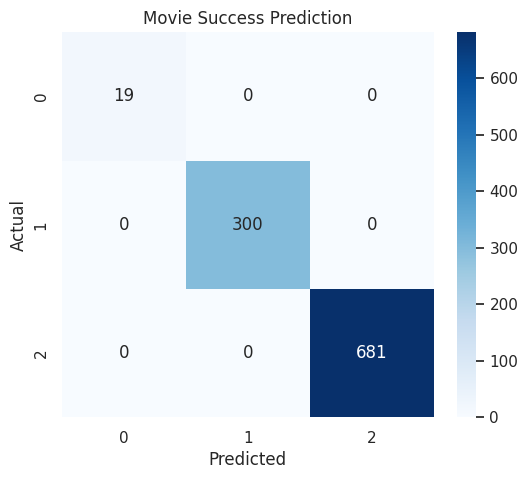

In [ ]:
cm = confusion_matrix(actual_classes, pred_classes)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Movie Success Prediction")
plt.show()

In [ ]:
print(classification_report(actual_classes, pred_classes))


              precision    recall  f1-score   support

           0       1.00      1.00      1.00        19
           1       1.00      1.00      1.00       300
           2       1.00      1.00      1.00       681

    accuracy                           1.00      1000
   macro avg       1.00      1.00      1.00      1000
weighted avg       1.00      1.00      1.00      1000



In [ ]:
new_movie = pd.DataFrame([{
    'Budget' : 150,
    'Runtime': 130,
    'Genre': encoder.transform(['Action'])[0],
    'Director_Rating': 8.5,
    'Actor_Popularity': 9.0,
    'Marketing_Budget': 50,
    'Release_Month':6
}])

new_movie = scaler.transform(new_movie)

prediction = model.predict(new_movie)

result = np.argmax(prediction)

labels = {
    0: 'Flop',
    1: 'Average',
    2: 'Hit'
}

print("Prediction:", labels[result])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 63ms/step
Prediction: Hit
